In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Import the plotting style from the satrain package
from satrain.plotting import set_style 
set_style()

In [10]:
# Replace the file name below with an actual .nc file you downloaded via wget
file_path = "/panfs/ccds02/nobackup/people/sanumolu/satrain_data/satrain/gmi/training/xl/on_swath/2018/01/05/geo_ir_t_20180105230216.nc"
# Open the NetCDF file using xarray
ds = xr.open_dataset(file_path)

# Display the dataset summary (this will show you dimensions, coordinates, and variables)
# In Jupyter, this will render as a nice interactive HTML representation.
display(ds)

<xarray.Dataset> Size: 557kB
Dimensions:       (time: 16, scan: 64, pixel: 64)
Coordinates:
  * time          (time) datetime64[ns] 128B 2018-01-05T19:30:00 ... 2018-01-...
    latitude      (scan, pixel) float32 16kB ...
    longitude     (scan, pixel) float32 16kB ...
Dimensions without coordinates: scan, pixel
Data variables:
    observations  (time, scan, pixel) float64 524kB ...
Attributes:
    BeginDate:       2018-01-05
    BeginTime:       21:00:00.000Z
    EndDate:         2018-01-05
    EndTime:         21:59:59.999Z
    FileHeader:      StartGranuleDateTime=2018-01-05T21:00:00.000Z;\nStopGran...
    InputPointer:    merg_2018010521_4km-pixel
    title:           NCEP/CPC 4km Global (60N - 60S) IR Dataset
    ProductionTime:  2018-01-07T00:25:32.000Z
    version:         1.2

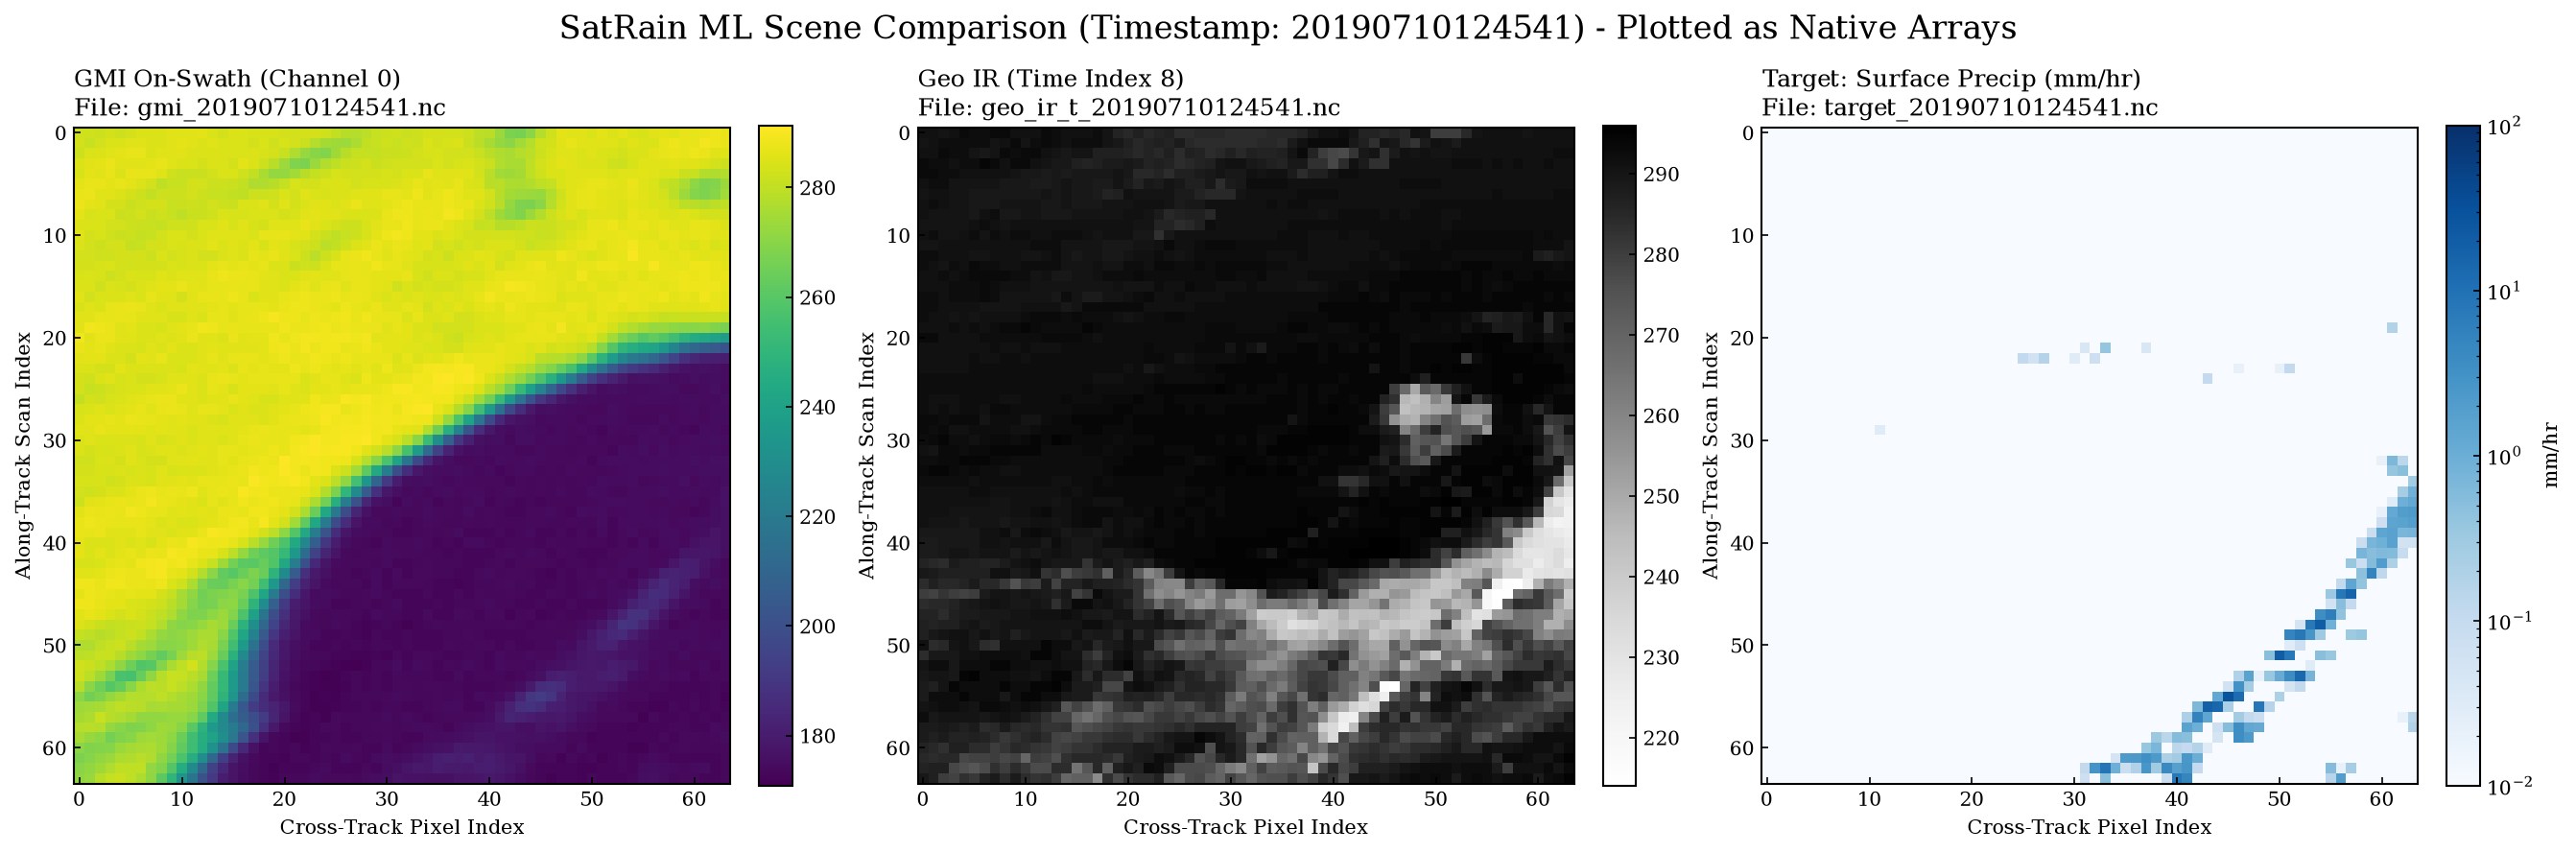

In [24]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import os

# --- 1. Define Paths ---
base_dir = "/panfs/ccds02/nobackup/people/sanumolu/satrain_data/satrain"
date_path = "2019/07/10"
timestamp = "20190710124541"

gmi_file = f"{base_dir}/gmi/training/xl/on_swath/{date_path}/gmi_{timestamp}.nc"
geo_file = f"{base_dir}/gmi/training/xl/on_swath/{date_path}/geo_ir_t_{timestamp}.nc"
target_file = f"{base_dir}/gmi/training/xl/on_swath/{date_path}/target_{timestamp}.nc"

# --- 2. Load Data ---
ds_gmi = xr.open_dataset(gmi_file)
ds_geo = xr.open_dataset(geo_file)
ds_target = xr.open_dataset(target_file)

# --- 3. Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot A: GMI
gmi_data = ds_gmi['observations'].isel(channel=0)
im_gmi = axes[0].imshow(gmi_data, cmap='viridis')
axes[0].set_title(f"GMI On-Swath (Channel 0)\nFile: {os.path.basename(gmi_file)}")
fig.colorbar(im_gmi, ax=axes[0], fraction=0.046, pad=0.04)

# Plot B: Geo IR Temporal
geo_data = ds_geo['observations'].isel(time=8)
im_geo = axes[1].imshow(geo_data, cmap='Greys')
axes[1].set_title(f"Geo IR (Time Index 8)\nFile: {os.path.basename(geo_file)}")
fig.colorbar(im_geo, ax=axes[1], fraction=0.046, pad=0.04)

# Plot C: Target Precip
target_data = ds_target['surface_precip'].values
# Mask NaNs and set minimum for log scale
target_masked = np.where(np.isnan(target_data), np.nan, np.maximum(target_data, 1e-3))
im_target = axes[2].imshow(target_masked, cmap='Blues', norm=LogNorm(vmin=1e-2, vmax=1e2))
axes[2].set_title(f"Target: Surface Precip (mm/hr)\nFile: {os.path.basename(target_file)}")
fig.colorbar(im_target, ax=axes[2], fraction=0.046, pad=0.04, label="mm/hr")

# Format axes
for ax in axes:
    ax.set_xlabel('Cross-Track Pixel Index')
    ax.set_ylabel('Along-Track Scan Index')

# Add a descriptive super-title
plt.suptitle(f"SatRain ML Scene Comparison (Timestamp: {timestamp}) - Plotted as Native Arrays", fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
import os, numpy as np, xarray as xr
os.environ["SATRAIN_DATA_PATH"] = "/explore/nobackup/people/sanumolu/satrain_ml/satrain_data/"
# pick a DAYTIME geo file (find one ~18-20 UTC):
DAY_F = "satrain_data/satrain/gmi/training/l/on_swath/2018/05/08/geo_20180508195406.nc"   # e.g. geo_YYYYMMDD190000.nc
with xr.open_dataset(DAY_F, engine="h5netcdf") as gd:
    obs = gd.observations[{"channel": list(range(6))}].load().transpose("channel", ...).data
for c in range(6):
    ch = obs[c]
    finite = ch[np.isfinite(ch)]
    leak = (finite > 200).sum()
    real_bright = ((finite > 100) & (finite <= 200)).sum()
    print(f"ch{c}: max={finite.max():.1f}  leaks(>200)={leak}  real_bright(100-200)={real_bright}")

ch0: max=39.4  leaks(>200)=0  real_bright(100-200)=0
ch1: max=47.0  leaks(>200)=0  real_bright(100-200)=0
ch2: max=54.7  leaks(>200)=0  real_bright(100-200)=0
ch3: max=3.9  leaks(>200)=0  real_bright(100-200)=0
ch4: max=54.1  leaks(>200)=0  real_bright(100-200)=0
ch5: max=41.8  leaks(>200)=0  real_bright(100-200)=0


In [5]:
import os, numpy as np, xarray as xr
os.environ["SATRAIN_DATA_PATH"] = "/explore/nobackup/people/sanumolu/satrain_ml/satrain_data/"

F = "/explore/nobackup/projects/pix4dcloud/sanumolu/satrain/gmi/training/l/on_swath/2020/01/06/geo_t_20200106000004.nc"

raw = xr.open_dataset(F, engine="h5netcdf", mask_and_scale=False)
obs = raw["observations"]           # (time, channel, scan, pixel), uint16
fill  = obs.attrs["_FillValue"]     # 65535
scale = obs.attrs["scale_factor"]   # 0.01
vals = obs.values.astype(np.int64)
T, C, H, W = vals.shape
px_per_frame = H * W

print(f"File: {os.path.basename(F)}   dims=(T={T}, C={C}, {H}x{W})  px/frame={px_per_frame}")
print(f"_FillValue={fill}  scale={scale}\n")

print(f"{'t':>2} {'ch':>3} | {'exact_fill':>10} | {'near_fill(65500-65534)':>22} | {'>1.0_after_norm(unpk>~155)':>26} | leak%")
for t in range(T):
    for c in range(6):   # VIS/NIR channels
        v = vals[t, c]
        exact = int((v == fill).sum())
        near  = int(((v >= 65500) & (v < fill)).sum())   # near-fill but not exact
        # leak = finite (not exact fill) but unpacks above physical range
        leak  = int(((v != fill) & (v * scale > 130)).sum())
        pct = 100.0 * leak / px_per_frame
        if leak > 0:
            print(f"{t:>2} {c:>3} | {exact:>10} | {near:>22} | {leak:>26} | {pct:5.1f}%")

# Also: aggregate over all VIS channels & timesteps
v_all = vals[:, :6]
tot_leak = int(((v_all != fill) & (v_all * scale > 130)).sum())
tot_px = T * 6 * px_per_frame
print(f"\nTOTAL VIS leaks (unpacked >130%): {tot_leak} / {tot_px} = {100*tot_leak/tot_px:.1f}%")
raw.close()

File: geo_t_20200106000004.nc   dims=(T=7, C=16, 64x64)  px/frame=4096
_FillValue=65535  scale=0.01

 t  ch | exact_fill | near_fill(65500-65534) | >1.0_after_norm(unpk>~155) | leak%
 0   0 |        971 |                      4 |                          4 |   0.1%
 0   1 |        970 |                   1301 |                       1301 |  31.8%
 0   2 |        971 |                    215 |                        215 |   5.2%
 0   3 |        982 |                    613 |                        613 |  15.0%
 0   4 |        971 |                    428 |                        428 |  10.4%
 0   5 |        982 |                     96 |                         96 |   2.3%
 1   0 |        971 |                      2 |                          2 |   0.0%
 1   1 |        970 |                   1276 |                       1276 |  31.2%
 1   2 |        971 |                    267 |                        267 |   6.5%
 1   3 |        982 |                    531 |                        

In [7]:
import numpy as np
PP = "/explore/nobackup/people/sanumolu/satrain_ml/satrain_data/preprocessed/satrain/gmi/training/l/on_swath"
geo = np.load(f"{PP}/geo.npy", mmap_mode="r")
idx = np.random.default_rng(0).choice(len(geo), size=min(200, len(geo)), replace=False)
blk = np.asarray(geo[np.sort(idx)]).astype(np.float32)
print("=== BEFORE fix: VIS channel contamination ===")
for c in range(6):
    ch = blk[:, c]
    print(f"ch{c}: max={ch.max():.2f}  frac>1.0={(ch>1.0).mean():.4f}")
with open("before_fix_vis_stats.txt", "w") as f:
    for c in range(6):
        ch = blk[:, c]
        f.write(f"ch{c}: max={ch.max():.2f} frac>1.0={(ch>1.0).mean():.4f}\n")
print("Saved to before_fix_vis_stats.txt")

=== BEFORE fix: VIS channel contamination ===
ch0: max=9.13  frac>1.0=0.0004
ch1: max=9.47  frac>1.0=0.1689
ch2: max=9.35  frac>1.0=0.0256
ch3: max=16.86  frac>1.0=0.0749
ch4: max=9.32  frac>1.0=0.0532
ch5: max=9.42  frac>1.0=0.0110
Saved to before_fix_vis_stats.txt


In [8]:
import os
import numpy as np
import xarray as xr
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

os.environ["SATRAIN_DATA_PATH"] = "/explore/nobackup/people/sanumolu/satrain_ml/satrain_data/"
from satrain.input import Geo
from satrain.input import normalize as satrain_normalize

F = "/explore/nobackup/projects/pix4dcloud/sanumolu/satrain/gmi/training/l/on_swath/2020/01/06/geo_t_20200106000004.nc"
CH   = 1     # Channel 1 (the worst-leak VIS channel)
T_IDX = 0    # first timestep

# ---------------------------------------------------------------
# Panel 1: RAW reading (unpacked physical units, fill -> NaN)
# ---------------------------------------------------------------
# mask_and_scale=True applies scale_factor and masks exact _FillValue -> NaN.
ds = xr.open_dataset(F, engine="h5netcdf")            # (time, channel, scan, pixel)
raw_ch1 = ds["observations"].isel(time=T_IDX, channel=CH).values   # physical %reflectance

print("=== PANEL 1: RAW (unpacked, physical reflectance %) ===")
finite = raw_ch1[np.isfinite(raw_ch1)]
print(f"  nan_frac={np.isnan(raw_ch1).mean():.3f}")
print(f"  finite min={finite.min():.2f}  max={finite.max():.2f}")
print(f"  pixels >130% (leaks): {int((finite>130).sum())}")

# ---------------------------------------------------------------
# Panel 2: after SatRain's normalization scheme (minmax, nan=-1.5)
# Reproduce EXACTLY what the Geo loader does for this channel.
# ---------------------------------------------------------------
geo = Geo(normalize="minmax", nan=-1.5)
# GeoT stores channels along the same axis; load the raw channel array the Geo way.
# We normalize using SatRain's per-channel stats for channel CH.
with xr.open_dataset(F, engine="h5netcdf") as gd:
    # geo_t file has a time dim; take same timestep, all-channel then pick CH
    obs_all = gd["observations"].isel(time=T_IDX).transpose("channel", ...).data  # (16, H, W)

# SatRain normalize expects (channels, H, W) with matching stats; do just channel CH
# but normalize() indexes stats by channel, so pass the full stack and slice after.
obs_norm_all = satrain_normalize(obs_all.copy(), geo.stats, how="minmax", nan=-1.5)
norm_ch1 = obs_norm_all[CH]

print("\n=== PANEL 2: SatRain-normalized (minmax, nan=-1.5) ===")
print(f"  min={norm_ch1.min():.3f}  max={norm_ch1.max():.3f}  mean={norm_ch1.mean():.3f}")
print(f"  frac == -1.5 (fill): {np.isclose(norm_ch1, -1.5).mean():.3f}")
print(f"  frac >  1.0 (leaks): {(norm_ch1 > 1.0).mean():.3f}")

# ---------------------------------------------------------------
# PLOT
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# Panel 1: raw. Use a range that lets the leaks stand out (0 to ~655).
im0 = axes[0].imshow(raw_ch1, cmap="viridis")
axes[0].set_title(f"(1) Raw reading — Channel {CH}\n(reflectance %, full range)")
cb0 = plt.colorbar(im0, ax=axes[0], fraction=0.046)
cb0.set_label("reflectance (%)")

# Panel 2: SatRain-normalized. Full range so the >1.0 leaks are visible.
im1 = axes[1].imshow(norm_ch1, cmap="viridis")
axes[1].set_title(f"(2) After SatRain normalization — Channel {CH}\n(minmax, fill=-1.5)")
cb1 = plt.colorbar(im1, ax=axes[1], fraction=0.046)
cb1.set_label("normalized value")

plt.suptitle(
    f"geo_t_20200106000004.nc  (00:00 UTC, nighttime CONUS)  —  Channel {CH}, t={T_IDX}\n"
    f"Leak pixels (~655% raw / >1.0 normalized) appear as bright outliers",
    fontsize=12,
)
plt.tight_layout()
out = "channel1_raw_vs_normalized.png"
plt.savefig(out, dpi=130)
print(f"\nSaved plot to {out}")

ds.close()

INFO     generated new fontManager

=== PANEL 1: RAW (unpacked, physical reflectance %) ===
  nan_frac=0.237
  finite min=0.00  max=655.33
  pixels >130% (leaks): 1301

=== PANEL 2: SatRain-normalized (minmax, nan=-1.5) ===
  min=-1.500  max=9.468  mean=2.207
  frac == -1.5 (fill): 0.237
  frac >  1.0 (leaks): 0.318

Saved plot to channel1_raw_vs_normalized.png
